In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Dropout,
    LSTM,
    Dense,
)
from tensorflow.keras.utils import to_categorical

print("--- All libraries imported successfully. ---")

--- All libraries imported successfully. ---


In [2]:
def plot_history(history):
    """Plots the model's training and validation accuracy and loss."""
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title("Model Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("Model Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

print("--- plot_history() function defined. ---")

--- plot_history() function defined. ---


In [3]:
print("\n--- Loading and Preprocessing Training Data (Multi-Class) ---")

try:
    df_train = pd.read_csv(r"C:\Users\tanma\Desktop\Major Project\OneDrive_2025-08-27\CSV Files\Training and Testing Sets\UNSW_NB15_training-set.csv")
except FileNotFoundError:
    print("Error: 'UNSW_NB15_training-set.csv' not found.")
else:
    df_train = df_train.drop(["id", "label"], axis=1)
    df_train["service"] = df_train["service"].replace("-", "unknown")

    categorical_cols = ["proto", "service", "state"]
    target_col = "attack_cat"
    numerical_cols = [
        col for col in df_train.columns if col not in categorical_cols + [target_col]
    ]

    df_train_categorical = pd.get_dummies(df_train[categorical_cols], dtype=int)
    
    scaler = MinMaxScaler()
    df_train_numerical = pd.DataFrame(
        scaler.fit_transform(df_train[numerical_cols]), columns=numerical_cols
    )

    X = pd.concat([df_train_numerical, df_train_categorical], axis=1)

    y_raw = df_train[target_col]
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_raw)
    num_classes = len(le.classes_)
    y_categorical = to_categorical(y_encoded, num_classes=num_classes)

    print(f"Total features after preprocessing: {X.shape[1]}")
    print(f"Found {num_classes} classes: {le.classes_}")
    print(f"Target 'y' shape (one-hot encoded): {y_categorical.shape}")


--- Loading and Preprocessing Training Data (Multi-Class) ---
Total features after preprocessing: 194
Found 10 classes: ['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']
Target 'y' shape (one-hot encoded): (175341, 10)


In [4]:
print("\n--- Splitting and Reshaping Training Data ---")

X_train, X_val, y_train, y_val = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical
)

n_features = X_train.shape[1]
X_train_reshaped = X_train.values.reshape((X_train.shape[0], 1, n_features))
X_val_reshaped = X_val.values.reshape((X_val.shape[0], 1, n_features))

print(f"Training data shape: {X_train_reshaped.shape}")
print(f"Validation data shape: {X_val_reshaped.shape}")


--- Splitting and Reshaping Training Data ---
Training data shape: (140272, 1, 194)
Validation data shape: (35069, 1, 194)


In [5]:
print("\n--- Building Model Architecture (Hybrid CNN-LSTM Multi-Class) ---")

INPUT_SHAPE = (1, n_features)

model = Sequential()

# CNN Feature Extraction
model.add(Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=INPUT_SHAPE))
model.add(MaxPooling1D(pool_size=1))
model.add(Dropout(0.2))
model.add(Conv1D(filters=128, kernel_size=1, activation='relu'))
model.add(MaxPooling1D(pool_size=1))
model.add(Dropout(0.2))
model.add(Conv1D(filters=256, kernel_size=1, activation='relu'))
model.add(MaxPooling1D(pool_size=1))

# LSTM Sequence Modeling
model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))

# Classification Block
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation='softmax')) # <-- CHANGED

# Compile
model.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"] # <-- CHANGED
)

model.summary()


--- Building Model Architecture (Hybrid CNN-LSTM Multi-Class) ---


D:\SOUL SYSTEM\Software\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1, 64)          │        12,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1, 128)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1, 256)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 1, 128)         │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,530 (1.20 MB)

 Trainable params: 315,530 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
print("\n--- Training Model ---")
print("This may take several minutes...")

EPOCHS = 70
BATCH_SIZE = 64

history = model.fit(
    X_train_reshaped,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_reshaped, y_val),
    verbose=1,
)

print("\nTraining complete.")


--- Training Model ---
This may take several minutes...
Epoch 1/70
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.6274 - loss: 1.0319 - val_accuracy: 0.7639 - val_loss: 0.6109
Epoch 2/70
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.7642 - loss: 0.6192 - val_accuracy: 0.7774 - val_loss: 0.5707
Epoch 3/70
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.7747 - loss: 0.5864 - val_accuracy: 0.7838 - val_loss: 0.5527
Epoch 4/70
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.7782 - loss: 0.5729 - val_accuracy: 0.7865 - val_loss: 0.5459
Epoch 5/70
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.7802 - loss: 0.5652 - val_accuracy: 0.7866 - val_loss: 0.5409
Epoch 6/70
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7850 - loss: 0.5546 - val_accuracy: 0.7933 - val_loss: 0.5316
Epoch 7/70
2192/2192 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7849 - loss: 0.5488 - val_accuracy: 0.7928 - val_loss: 0.5254
Epoch 8/70
2192/2192 ━━━━━


--- Plotting Training History ---


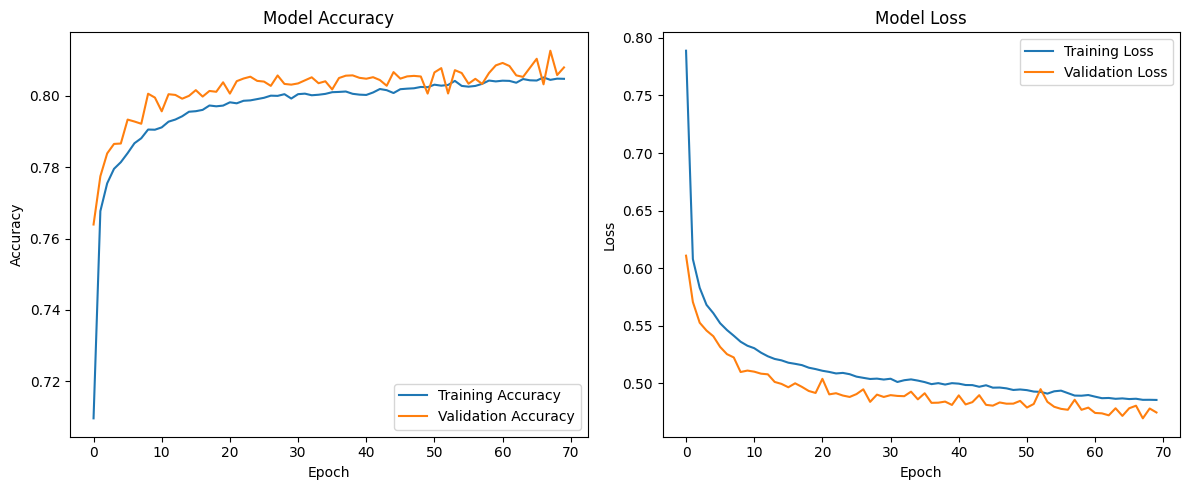

In [7]:
print("\n--- Plotting Training History ---")
plot_history(history)

In [9]:
print("\n--- Evaluating Model on Test Set ---")

try:
    df_test = pd.read_csv(r"C:\Users\tanma\Desktop\Major Project\OneDrive_2025-08-27\CSV Files\Training and Testing Sets\UNSW_NB15_testing-set.csv")
except FileNotFoundError:
    print("Error: 'UNSW_NB15_testing-set.csv' not found.")
else:
    df_test = df_test.drop(["id", "label"], axis=1)
    df_test["service"] = df_test["service"].replace("-", "unknown")

    # Define columns (needed if running this cell independently)
    target_col = "attack_cat"
    categorical_cols = ["proto", "service", "state"]
    numerical_cols = [
        col for col in df_train.columns if col not in categorical_cols + [target_col]
    ]
    
    # Handle unknown labels
    test_labels_present = df_test[target_col].unique()
    train_labels_known = le.classes_
    unknown_labels = set(test_labels_present) - set(train_labels_known)

    if unknown_labels:
        print(f"Warning: Found unknown labels in test set: {unknown_labels}")
        df_test = df_test[~df_test[target_col].isin(unknown_labels)]
        print(f"Removed rows with unknown labels.")

    X_test_raw = df_test.drop(target_col, axis=1)
    y_test_raw = df_test[target_col]

    df_test_numerical = pd.DataFrame(
        scaler.transform(X_test_raw[numerical_cols]), columns=numerical_cols
    )
    df_test_categorical = pd.get_dummies(
        X_test_raw[categorical_cols], dtype=int
    )
    X_test_processed = pd.concat(
        [df_test_numerical, df_test_categorical], axis=1
    )
    X_test_aligned = X_test_processed.reindex(columns=X.columns).fillna(0)

    # Process Test Target Variable
    y_test_encoded = le.transform(y_test_raw)
    y_test_categorical = to_categorical(y_test_encoded, num_classes=num_classes)

    print("Test data preprocessed successfully.")


--- Evaluating Model on Test Set ---
Test data preprocessed successfully.


In [10]:
print("\n--- Reshaping and Evaluating Test Data ---")

X_test_reshaped = X_test_aligned.values.reshape(
    (X_test_aligned.shape[0], 1, n_features)
)
print(f"Test data shape: {X_test_reshaped.shape}")

# Evaluate using one-hot encoded labels
loss, accuracy = model.evaluate(X_test_reshaped, y_test_categorical, verbose=0)

print("\n--- Model Test Results ---")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")


--- Reshaping and Evaluating Test Data ---
Test data shape: (82332, 1, 194)

--- Model Test Results ---
Test Loss: 0.5470
Test Accuracy: 76.92%



--- Generating Final Reports ---
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step

--- Classification Report ---
                precision    recall  f1-score   support

      Analysis       0.00      0.00      0.00       677
      Backdoor       0.00      0.00      0.00       583
           DoS       0.51      0.05      0.09      4089
      Exploits       0.53      0.93      0.68     11132
       Fuzzers       0.31      0.46      0.37      6062
       Generic       1.00      0.96      0.98     18871
        Normal       0.97      0.78      0.86     37000
Reconnaissance       0.66      0.81      0.73      3496
     Shellcode       0.35      0.48      0.41       378
         Worms       0.00      0.00      0.00        44

      accuracy                           0.77     82332
     macro avg       0.43      0.45      0.41     82332
  weighted avg       0.81      0.77      0.77     82332


--- Confusion Matrix ---


D:\SOUL SYSTEM\Software\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\SOUL SYSTEM\Software\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\SOUL SYSTEM\Software\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


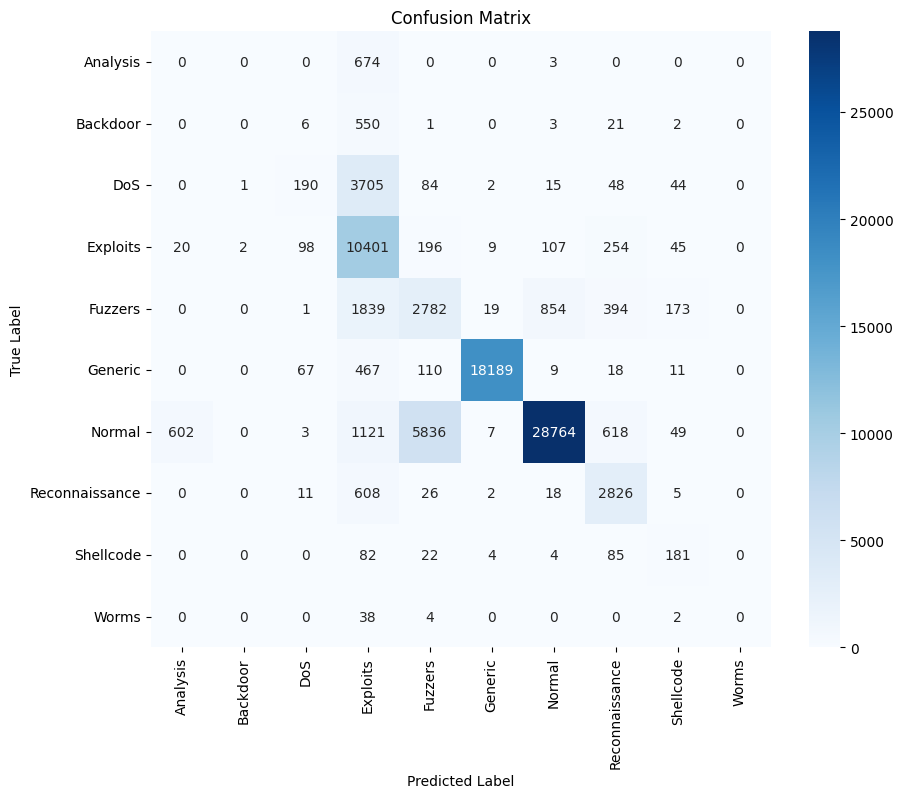


--- Process Finished ---


In [11]:
print("\n--- Generating Final Reports ---")

y_pred_probs = model.predict(X_test_reshaped)

# Convert probabilities to class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = y_test_encoded # Use integer-encoded labels

target_names = le.classes_

# 1. Classification Report
print("\n--- Classification Report ---")
print(
    classification_report(
        y_true_classes, y_pred_classes, target_names=target_names
    )
)

# 2. Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names,
)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

print("\n--- Process Finished ---")